In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
import cosmo_kb_func as kbf

In [2]:
chain_dir = "../../../NA_zenodo/hierarchical_inference_chains/forecasts/"

# --- 1. Results Analysis and Visualization based on corner ---
file_name = os.path.join(chain_dir, "bpl_forecast_neff_10_lambda0_chain.npz")
data = np.load(file_name)
remove_list = data['remove_list']
samples_all = data['samples']
lnprob_all = data["lnprob"]
print(f"Data shape from "+file_name+f": {samples_all.shape}")
print(f"--- Dropped data with index: {remove_list} ---") 

nburn = 300
samples_sub = samples_all[:,nburn:,:]
print(f"Sampling chain shape (after removing burn-in): {samples_sub.shape}")

ndim = samples_sub.shape[-1]
labels = ["$\\gamma_{PPN}$", "$\\beta_{0}$", "$\\beta_{z}$", "$\\delta_{m,0}$","$\\delta_{m,z}$","$\\Omega_{m}$"]
samples0 = samples_sub.reshape(-1,ndim)

Data shape from ../../../NA_zenodo/hierarchical_inference_chains/forecasts/bpl_forecast_neff_10_lambda0_chain.npz: (2000, 600, 6)
--- Dropped data with index: [101 107 108 114] ---
Sampling chain shape (after removing burn-in): (2000, 300, 6)


In [3]:
# --- 1. Results Analysis and Visualization based on corner ---
file_name = os.path.join(chain_dir, "bpl_forecast_neff_100_lambda0_chain.npz")
data = np.load(file_name)
remove_list = data['remove_list']
samples_all = data['samples']
lnprob_all = data["lnprob"]
print(f"Data shape from "+file_name+f": {samples_all.shape}")
print(f"--- Dropped data with index: {remove_list} ---") 

nburn = 301
samples_sub = samples_all[:,nburn:,:]
print(f"Sampling chain shape (after removing burn-in): {samples_sub.shape}")

ndim = samples_sub.shape[-1]
labels = ["$\\gamma_{PPN}$", "$\\beta_{0}$", "$\\beta_{z}$", "$\\delta_{m,0}$","$\\delta_{m,z}$","$\\Omega_{m}$"]
samples1 = samples_sub.reshape(-1,ndim)

Data shape from ../../../NA_zenodo/hierarchical_inference_chains/forecasts/bpl_forecast_neff_100_lambda0_chain.npz: (2000, 600, 6)
--- Dropped data with index: [101 107 108 114] ---
Sampling chain shape (after removing burn-in): (2000, 299, 6)


In [4]:
# --- 1. Results Analysis and Visualization based on corner ---
file_name = os.path.join(chain_dir, "bpl_forecast_neff_1k_lambda0_chain.npz")
data = np.load(file_name)
remove_list = data['remove_list']
samples_all = data['samples']
lnprob_all = data["lnprob"]
print(f"Data shape from "+file_name+f": {samples_all.shape}")
print(f"--- Dropped data with index: {remove_list} ---") 

nburn = 302
samples_sub = samples_all[:,nburn:,:]
print(f"Sampling chain shape (after removing burn-in): {samples_sub.shape}")

ndim = samples_sub.shape[-1]
labels = ["$\\gamma_{PPN}$", "$\\beta_{0}$", "$\\beta_{z}$", "$\\delta_{m,0}$","$\\delta_{m,z}$","$\\Omega_{m}$"]
samples2 = samples_sub.reshape(-1,ndim)

Data shape from ../../../NA_zenodo/hierarchical_inference_chains/forecasts/bpl_forecast_neff_1k_lambda0_chain.npz: (2000, 600, 6)
--- Dropped data with index: [101 107 108 114] ---
Sampling chain shape (after removing burn-in): (2000, 298, 6)


In [5]:
from getdist import plots, MCSamples  
# --- 2. Define parameter names and labels ---  
labels = [r"\gamma_{PPN}", r"\beta_0", r"\beta_z", r"\delta_{m,0}", r"\delta_{m,z}", r"\Omega_{m}"]
ndim = len(labels)
# names are the parameter names used internally by getdist
names = [f"par{i+1}" for i in range(ndim)]  

# --- 3. Create the getdist MCSamples object ---  
# This is the core data structure of getdist; it encapsulates samples and related metadata  
#limits = [ (None, None), (None, None), (None, None), (-1, 2), (-2, 2),(0.1,0.5)] 
limits = [ (0.75, 1.05), (0.2, 0.7), (-1.8,0.8), (-1, 2), (-2, 2),(0.1,0.5)] 
mcsamples0 = MCSamples(  
    samples=samples0,  
    names=names,  
    labels=labels,  
    label='MCMC posterior',  
    ranges=limits,
    settings={"smooth_scale_2D": 0.3, "smooth_scale_1D": 0.3}
)  

mcsamples1 = MCSamples(  
    samples=samples1,  
    names=names,  
    labels=labels,  
    label='MCMC posterior',  
    ranges=limits,
    settings={"smooth_scale_2D": 0.3, "smooth_scale_1D": 0.3}
)  

mcsamples2 = MCSamples(  
    samples=samples2,  
    names=names,  
    labels=labels,  
    label='MCMC posterior',  
    ranges=limits,
    settings={"smooth_scale_2D": 0.3, "smooth_scale_1D": 0.3}
)  


Removed no burn in
Removed no burn in
Removed no burn in


In [6]:
perc0,txt0 = kbf.get_mcmc_title(mcsamples0,weight=True,fmt=[".3f"])
perc1,txt1 = kbf.get_mcmc_title(mcsamples1,weight=True,fmt=[".3f"])
perc2,txt2 = kbf.get_mcmc_title(mcsamples2,weight=True,fmt=[".3f"])
perc,txt = perc2,txt2
#perc0,txt0,perc1,txt1,perc2,txt2

lnprob_all = data['lnprob']
idx = np.where(lnprob_all == lnprob_all.max())
best_samples, best_lnprobs = samples_all[idx],lnprob_all[idx]
best_samples, best_lnprobs

(array([[ 0.89907107,  0.49897263, -0.49444055,  0.28320892, -0.28733718,
          0.27719398]]),
 array([-2.11461657]))


Generating triangle plot with getdist...


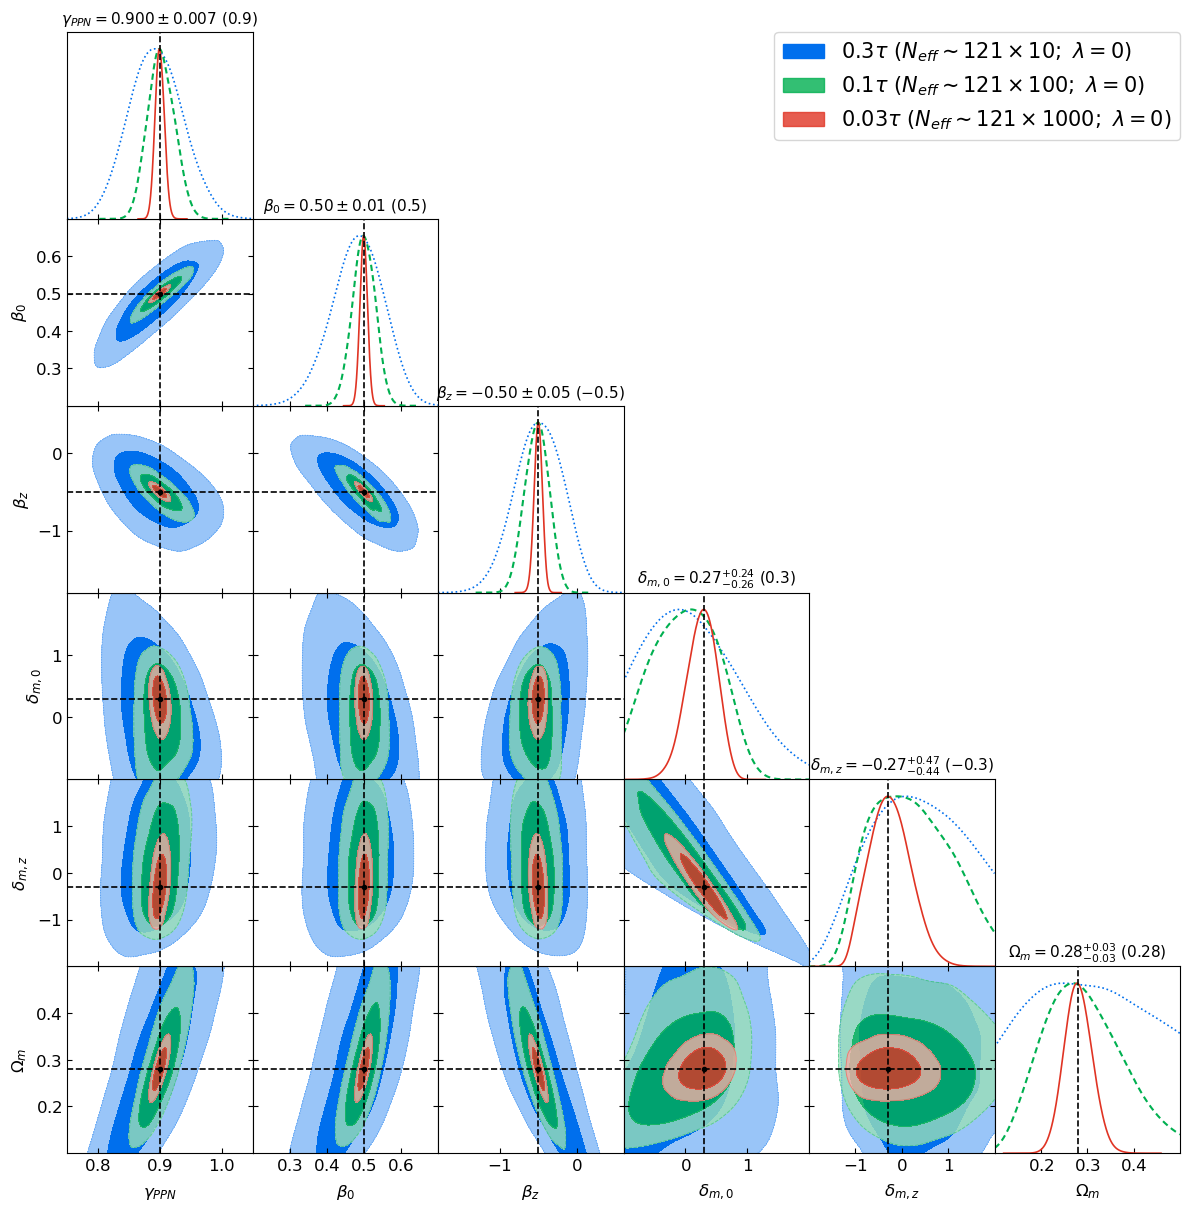

In [7]:
# --- 5. Plotting with getdist ---  
print("\nGenerating triangle plot with getdist...") 
g = plots.GetDistPlotter()  

# Set plot styles, such as line width, etc. 
g.settings.axes_labelsize = 15#12  
g.settings.axes_fontsize = 15#12  
g.settings.legend_fontsize = 18#12  
#g.settings.title_limit_fontsize = 12  
g.settings.alpha_filled_add = 0.8

# Plot the triangle plot (corner plot)  
g.triangle_plot(   
    [mcsamples0,mcsamples1,mcsamples2],      # Pass a list of MCSamples objects for comparison 
    #filled=True,     # Fill 2D contour plots   
    filled=[True,True,True,True],     # Fill 2D contour plots
    # #shaded=True,
    contour_colors=["#006fed",'#00B050','#e03424'],    
    legend_labels=[r"$0.3\tau ~(N_{eff}\sim121\times10;~\lambda=0)$", r"$0.1\tau ~(N_{eff}\sim121\times100;~\lambda=0)$", r"$0.03\tau ~(N_{eff}\sim121\times1000;~\lambda=0)$"],
    show_titles=True,
    title_limit=0,
    contour_lws = [1.2,1.2,1.2],
    contour_ls  = [':','--','-'],
    legend_loc='upper right'
)  

truth_color = "k"
truth_ls = "--"
truth_lw = 1.2
#truths = np.array([yppn_true, beta0_true, betaz_true, dm0_true, dmz_true])
truths = np.array([0.9, 0.5, -0.5, 0.3, -0.3,0.28])
maps = best_samples[0]

# 1D: Draw vertical truth lines on the diagonal subplots
for i in range(ndim):
    ax = g.subplots[i, i]
    ax.axvline(truths[i], color=truth_color, ls=truth_ls, lw=truth_lw, zorder=10)
    lines = ax.get_lines()
    lines[1].set_linewidth(1.5)

# 2D: Draw truth crosses on the lower-triangle subplots
#     (vertical line for the x truth + horizontal line for the y truth)
for i in range(1, ndim):          # Row: y-parameter index
    for j in range(0, i):         # Column: x-parameter index
        ax = g.subplots[i, j]
        ax.axvline(truths[j], color=truth_color, ls=truth_ls, lw=truth_lw, zorder=10)
        ax.axhline(truths[i], color=truth_color, ls=truth_ls, lw=truth_lw, zorder=10)
        # truth point
        ax.plot(truths[j], truths[i], marker="o", ms=3, color=truth_color, zorder=11)
        #ax.plot(maps[j], maps[i], marker="o", mew=1.,ms=6, mfc="none",color='gold', zorder=12)

for i in range(ndim):
    ax = g.subplots[i, i]
    #ax.set_title(f"{txtJ[i]}\ntrue={truths[i]:.3g}", fontsize=11)
    ax.set_title(f"{txt[i]} (${truths[i]:.3g}$)", fontsize=11)

# We start the loop from i=1 because the first parameter (i=0) only appears 
# as an X-axis and has no corresponding Y-axis to modify.
for i in range(1, ndim):
    x_axis_subplot = g.subplots[i, i]  
    y_axis_subplot = g.subplots[i, 0]
    
    # Get the limits and ticks from the source X-axis.
    x_lims = x_axis_subplot.get_xlim()
    x_ticks = x_axis_subplot.get_xticks()
    
    # This print statement is for verification purposes.
    # print(f"Parameter '{names[i]}': Got limits {x_lims} and ticks {x_ticks} from its X-axis.")
    # Apply these limits and ticks to the corresponding Y-axis.
    y_axis_subplot.set_ylim(x_lims)
    y_axis_subplot.set_yticks(x_ticks)

#plt.tight_layout()
plt.savefig('img_forecast.pdf', dpi=400, bbox_inches='tight')
#plt.savefig('img_forecast.png', dpi=400, bbox_inches='tight')
plt.show()